# Neural Networks (part 2)

## 1. Introduction 
In this notebook you create a NN for recognizing handwritten digits or fashion items.

#### Refrences:

***MNIST dataset***: Deng, L. (2012). The mnist database of handwritten digit images for machine learning research. IEEE Signal Processing Magazine, 29(6), 141–142.

***Fashion dataset***: Han Xiao and Kashif Rasul and Roland Vollgraf, Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms, arXiv, cs.LG/1708.07747


## 2. Loading the data

You make use of the MNIST or the Fashion-MINST dataset. **You get to choose one of them!** Both datasets consist of 70000 images of 28$\times$28 pixels (each pixel has a gray value 0 - 255). The dataset can be downloaded from the internet (see code below). In the text I reference to the images as numbers, if you do the fashion dataset, you can read here fashion items instead.

In [23]:
# importing the required modules
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# to get matplot figures render correctly in the notebook use:
%matplotlib inline 

In [24]:
# Load data from https://www.openml.org/

from sklearn.datasets import fetch_openml

# Pick either the numbers or the fashion database here:
X, Y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')
#X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)


X = X.T  # required as the rows should be the features and the columns the samples; shape (784, 70000).
Y = Y.astype('int')  # y has values as strings ('0', '1', ...'9') and we want integers (0, 1, ..., 9)

# inspect shape.
print(X.shape)
print(Y.shape)


(784, 70000)
(70000,)


To have an idea of the data let's print a single sample

label = 0


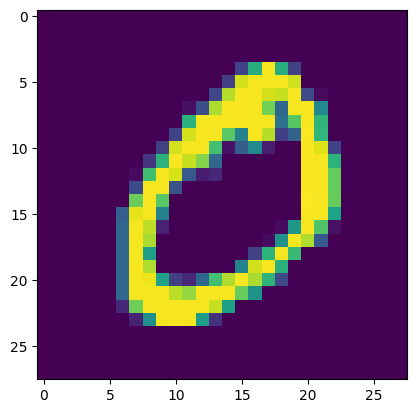

In [25]:
sample = X[:, 1]  # sample number 1
label = Y[1]  # label of sample 1
plt.imshow(sample.reshape(28,28))  # need to reshape to a square image of 28 by 28
print(f'label = {label}')

## 3. Create the feature matrix X and labels matrix Y


In [26]:
# rescale feature matrix to values between 0 and 1
X = X/np.max(X)
#X = (X - np.mean(X, axis=1, keepdims=True)) / np.std(X, axis=1, keepdims=True)

# create one-hot encoded Y matrix
n_rows = int(np.max(Y) + 1)
Y_col = Y.reshape(70000, 1)
Y_hot = np.eye(n_rows)[Y_col.flatten().astype(int)]
Y_hot = Y_hot.T
print(Y_hot.shape)

(10, 70000)


In [27]:
# create a train, validation and test dataset
# for the test data set take the first 5000 samples
# for the train data set take sample 5001 to 60000
# for the validation set take sample 60001 to 70000

X_test  = X[:, :5001]
X_train = X[:, 5001:60001]
X_valid = X[:, 60001:70001]

Y_test  = Y_hot[:, :5001]
Y_train = Y_hot[:, 5001:60001]
Y_valid = Y_hot[:, 60001:70001]


## 4. The Neural Network

The NN that you will make has the following layout (this is something that will work, but feel free to make changes if you like):

- input layer ($l=0$): 784 nodes
- hidden layer ($l=1$): 300 nodes; ReLu activation function
- hidden layer ($l=2$): 100 nodes; ReLu activation function
- output layer ($l=3$): 10 nodes; Softmax activation function


### Define the activation functions

Below you define the required activation functions and their derivatives.

In [28]:
# define some activation functions

def softmax(z):
    """
    returns the softmax function of z

    Parameters
    ----------
    z : 2D ndarray

    Returns
    -------
    out : same type and shape as z

    """
    
    e = np.exp(z)
    return e/np.sum(e, axis=0)


def ReLu(z):

    return np.maximum(0, z)


def ReLu_diff(z):
    """
    returns the derivative of ReLu function of z

    Parameters
    ----------
    z : float or ndarray

    Returns
    -------
    out : same type and shape as z

    """
    output = z > 0
    return output.astype(int)


In [29]:
z = np.array([
    [-3, -2, -1, 0, 1, 2, 3, -4, 5, -6],  # Row 1
    [7, -8, 9, -10, 11, -12, 13, -14, 15, -16]  # Row 2
])

ReLu_diff(z)

array([[0, 0, 0, 0, 1, 1, 1, 0, 1, 0],
       [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]])

### Initalize the weights and biases


In [30]:
# intialize the neural network
rng = np.random.default_rng()

# number of nodes in each layer
n0 = 784
n1 = 300
n2 = 100
n3 = 10

# input layer
# no weights and biases

# hidden layer 1 
W1 = rng.normal(0, sqrt(1/n0), size=(n1, n0))
b1 = np.zeros((n1, 1))

# hidden layer 2 
W2 = rng.normal(0, sqrt(1/n1), size=(n2, n1))
b2 = np.zeros((n2, 1))

# output layer 
W3 = rng.normal(0, sqrt(1/n2), size=(n3, n2))
b3 = np.zeros((n3, 1))


## 5. Train the NN

Firt you define three parameters that can be adjusted for optimal training.
- **learning_rate**: determines to what extend we update the weights and biases in the gradient descent step
- **no_epochs**: the number of times we pass the training data set through the network for training
- **batch_size**: how many samples we pass through the network before doing a gradient descent update

In [31]:
# train settings
learning_rate = 0.5
no_epochs = 25
batch_size = 500


Below you implement the training of the network. As a start copy and paste your code from part 1. Note that we use the **Cross Entropy** (CE) loss function.

In [32]:
# perform the training

accuracies = []
losses = []

accuracies_valid = []
losses_valid = []

for epoch in range(1, no_epochs + 1):
    
    # for each epoch train over all batches
    number_of_batches = int(X_train.shape[1]/batch_size)


    for batch in range(number_of_batches): 
        X_batch = X_train[:, batch_size*batch : batch_size*(batch+1)]
        Y_batch = Y_train[:, batch_size*batch : batch_size*(batch+1)]
        
        # forward pass
        # compute the output of the network for the batch
        a0 = X_batch
        z1 = W1 @ a0 + b1
        a1 = ReLu(z1)

        z2 = W2 @ a1 + b2
        a2 = ReLu(z2)

        z3 =  W3 @ a2 + b3
        a3 = softmax(z3)

        
        # backward pass
        # compute the derivatives dLdW and dLdb for the layers (use CE loss)
        dLdz3 = a3 - Y_batch #softmax and CE 
        dLdW3 = dLdz3 @ a2.T
        dLdb3 = dLdz3

    
        dLdz2 = ReLu_diff(z2)*(W3.T@dLdz3)
        dLdW2 = dLdz2 @ a1.T
        dLdb2 = dLdz2

        dLdz1 = ReLu_diff(z1)*(W2.T@dLdz2)
        dLdW1 = dLdz1 @ a0.T
        dLdb1 = dLdz1
        
        # gradient descent step / update weights and biases
        multiplier = learning_rate/batch_size
        W1 = W1 - multiplier * dLdW1
        b1 = b1 - multiplier*np.sum(dLdb1, axis=1).reshape(-1, 1) # makes it into a column vector
     
        W2 = W2 - multiplier * dLdW2
        b2 = b2 - multiplier*np.sum(dLdb2, axis=1).reshape(-1, 1)

        W3 = W3 - multiplier * dLdW3
        b3 = b3 - multiplier*np.sum(dLdb3, axis=1).reshape(-1, 1)

    
    # for each epoch evaluate the network performance
    # compute accuracy of train set and store for later analysis

    # forward pass for all data
    a0 = X_train
    z1 = W1 @ a0 + b1
    a1 = ReLu(z1)
    z2 = W2 @ a1 + b2
    a2 = ReLu(z2)
    z3 =  W3 @ a2 + b3
    a3 = softmax(z3)

    # Get predicted class index (argmax along rows → axis=0)
    prediction = np.argmax(a3, axis=0)  # Shape: (num_samples,)

    # Get true class index (argmax along rows → axis=0)
    reference = np.argmax(Y_train, axis=0)  # Shape: (num_samples,)
    correct_guesses = np.sum(prediction == reference)
    accuracy = correct_guesses / len(reference)
    accuracies.append(accuracy)

    loss = - np.mean(Y_train*np.log(a3)) # bc softmax 
    losses.append(loss) 
    
    # for each epoch print info on learning progress
    print(f"Epoch {epoch} accuracy: {accuracy:.3}, loss: {loss:.3}")




    # Validation set 

     # forward pass for all validation data
    a0 = X_valid
    z1 = W1 @ a0 + b1
    a1 = ReLu(z1)
    z2 = W2 @ a1 + b2
    a2 = ReLu(z2)
    z3 =  W3 @ a2 + b3
    a3 = softmax(z3)

    # Get predicted class index (argmax along rows → axis=0)
    prediction_valid = np.argmax(a3, axis=0)  # Shape: (num_samples,)



    # Get true class index (argmax along rows → axis=0)
    reference_valid = np.argmax(Y_valid, axis=0)  # Shape: (num_samples,)
    correct_guesses = np.sum(prediction_valid == reference_valid)
    accuracy_valid = correct_guesses / len(reference_valid)
    accuracies_valid.append(accuracy_valid)

    loss_valid = - np.mean(Y_valid*np.log(a3)) # bc softmax 
    losses_valid.append(loss_valid) 

    # for each epoch print info on learning progress
    print(f"Validation: Epoch {epoch} accuracy: {accuracy_valid:.3}, loss: {loss_valid:.3}")


Epoch 1 accuracy: 0.922, loss: 0.0253
Validation: Epoch 1 accuracy: 0.926, loss: 0.0242
Epoch 2 accuracy: 0.95, loss: 0.0164
Validation: Epoch 2 accuracy: 0.951, loss: 0.0161
Epoch 3 accuracy: 0.964, loss: 0.012
Validation: Epoch 3 accuracy: 0.962, loss: 0.0124
Epoch 4 accuracy: 0.972, loss: 0.00953
Validation: Epoch 4 accuracy: 0.967, loss: 0.0105
Epoch 5 accuracy: 0.976, loss: 0.00795
Validation: Epoch 5 accuracy: 0.97, loss: 0.00953
Epoch 6 accuracy: 0.98, loss: 0.00679
Validation: Epoch 6 accuracy: 0.973, loss: 0.00887
Epoch 7 accuracy: 0.982, loss: 0.00588
Validation: Epoch 7 accuracy: 0.974, loss: 0.00843
Epoch 8 accuracy: 0.985, loss: 0.00513
Validation: Epoch 8 accuracy: 0.975, loss: 0.00809
Epoch 9 accuracy: 0.987, loss: 0.00446
Validation: Epoch 9 accuracy: 0.975, loss: 0.00783
Epoch 10 accuracy: 0.989, loss: 0.0039
Validation: Epoch 10 accuracy: 0.975, loss: 0.00761
Epoch 11 accuracy: 0.99, loss: 0.00342
Validation: Epoch 11 accuracy: 0.975, loss: 0.00746
Epoch 12 accuracy: 

## 6. Analyze the result
Make a plot of the training and validation loss and training and validation accuracy as function of the epoch.

Text(0, 0.5, 'validation loss')

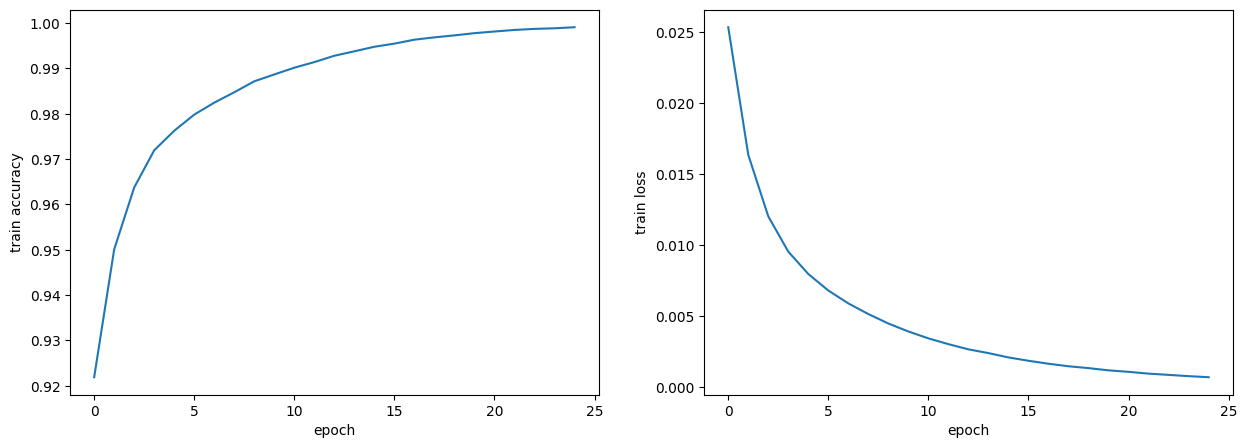

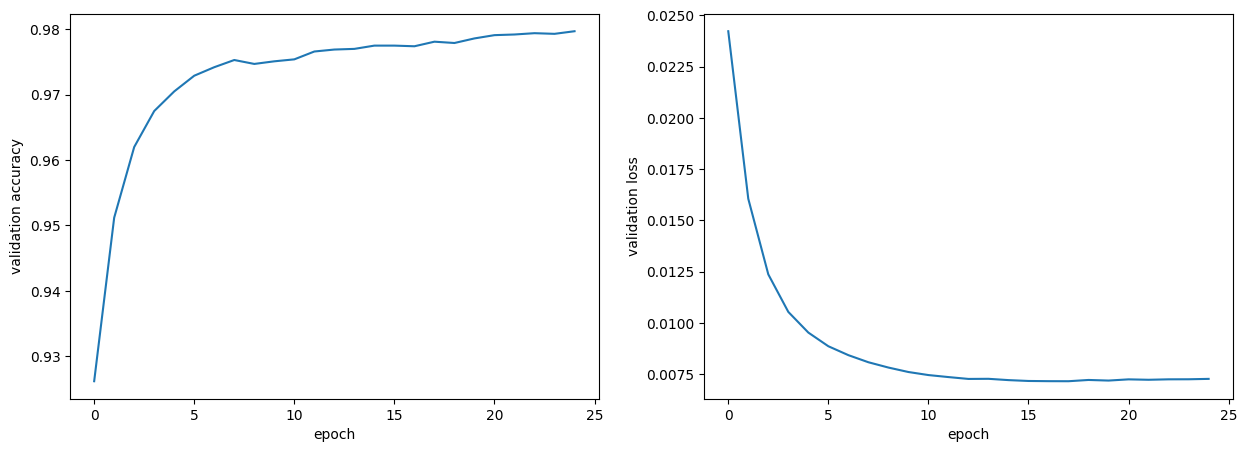

In [33]:
# plot the loss and accuracy as function of the epoch number

# Plot the train loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plt.sca(ax1)
plt.plot(accuracies)
plt.xlabel('epoch')
plt.ylabel('train accuracy')

plt.sca(ax2)
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('train loss')


# Plot the validation loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plt.sca(ax1)
plt.plot(accuracies_valid)
plt.xlabel('epoch')
plt.ylabel('validation accuracy')

plt.sca(ax2)
plt.plot(losses_valid)
plt.xlabel('epoch')
plt.ylabel('validation loss')


Adapt the hyperparameters and/or NN layout to try to improve the result.

Finally use the test set to check the performance of the model

In [34]:
# compute the accuracy and losses of the test set
 # forward pass for test data

a0 = X_test
z1 = W1 @ a0 + b1
a1 = ReLu(z1)
z2 = W2 @ a1 + b2
a2 = ReLu(z2)
z3 =  W3 @ a2 + b3
a3 = softmax(z3)

# Get predicted class index (argmax along rows → axis=0)
prediction_test = np.argmax(a3, axis=0)  # Shape: (num_samples,)



# Get true class index (argmax along rows → axis=0)
reference_test = np.argmax(Y_test, axis=0)  # Shape: (num_samples,)
correct_guesses = np.sum(prediction_test == reference_test)
accuracy_test = correct_guesses / len(reference_test)

loss_test = - np.mean(Y_test*np.log(a3)) # bc softmax 
 
print(f"Test: accuracy: {accuracy_test:.3}, loss: {loss_test:.3}")

Test: accuracy: 0.981, loss: 0.0072


Finally it is interesting to check a few samples and their predicted label

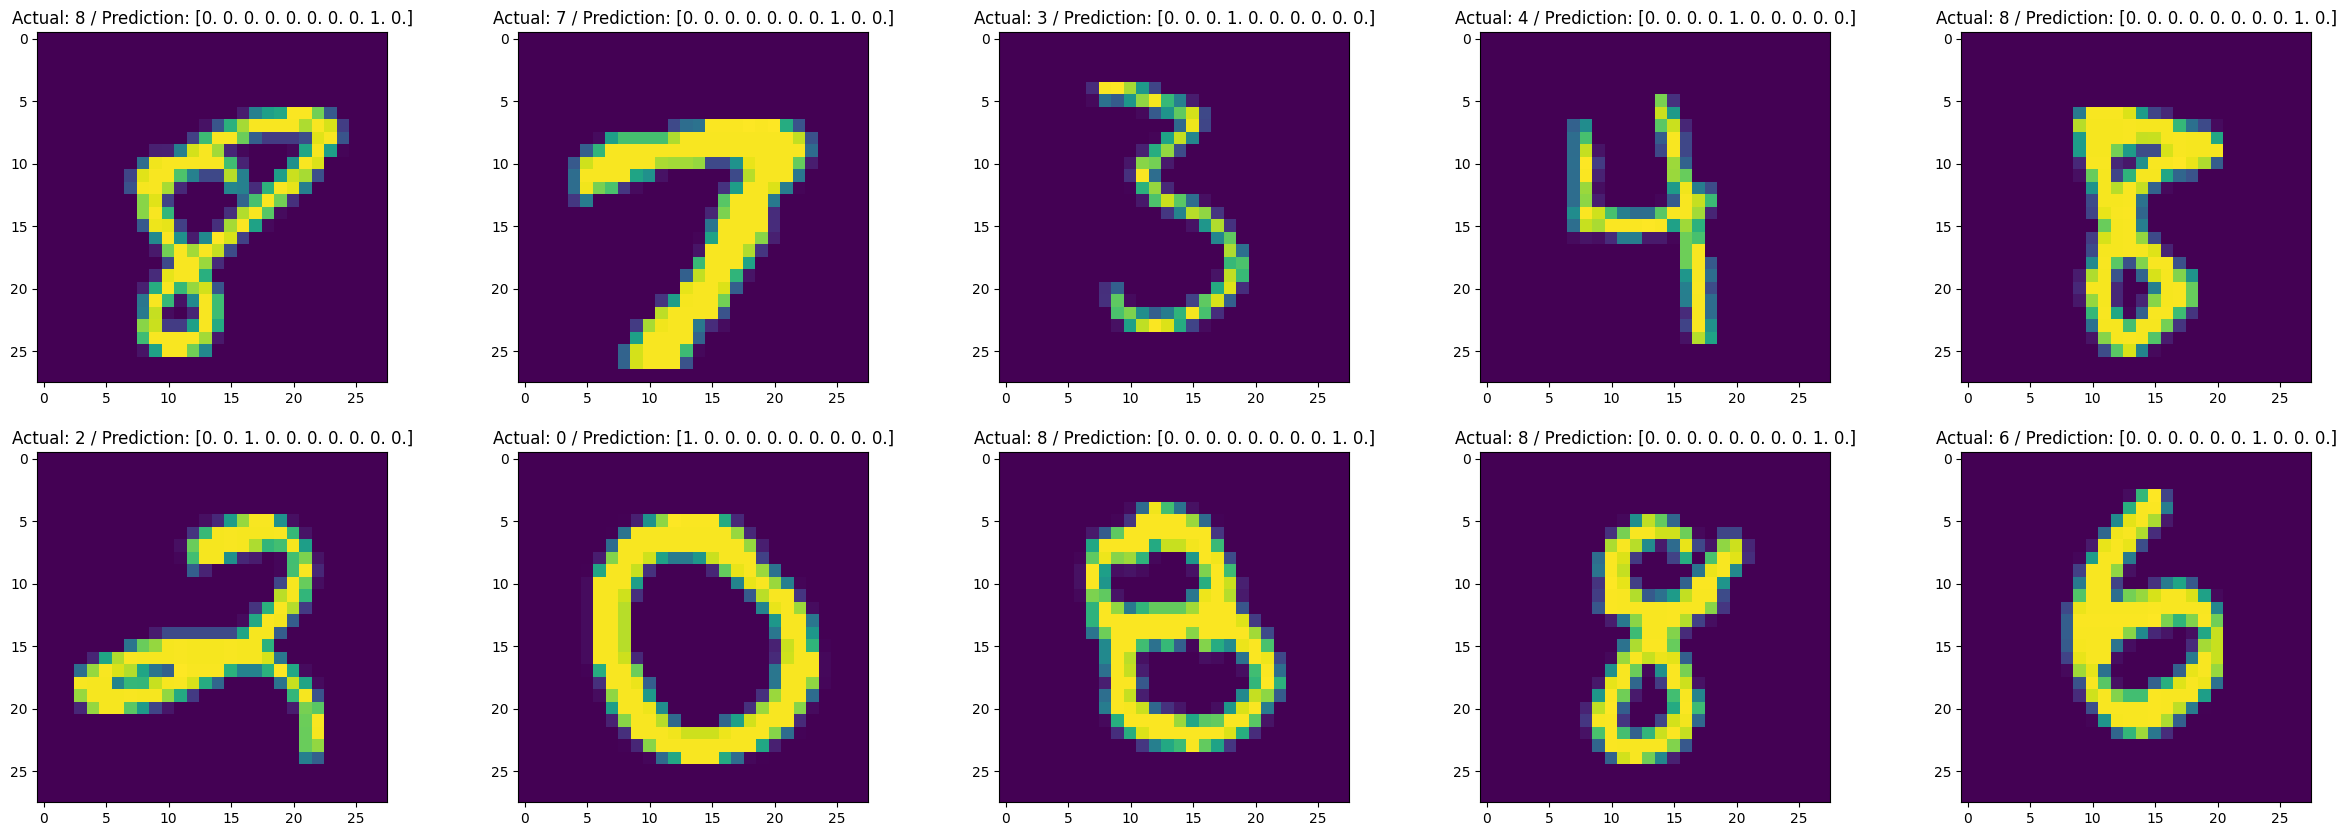

In [35]:
# check the prediction of 10 random images

rand = np.random.randint(low=0, high=70000, size=(10))
images = X[:, rand]
labels = Y[rand]

a0 = images
z1 = W1 @ a0 + b1
a1 = ReLu(z1)
z2 = W2 @ a1 + b2
a2 = ReLu(z2)
z3 =  W3 @ a2 + b3
a3 = softmax(z3)

predictions = np.zeros_like(a3)  # Create a zero matrix of the same shape
predictions[np.argmax(a3, axis=0), np.arange(a3.shape[1])] = 1  # Set max to 1

fig, axs = plt.subplots(2, 5, figsize=(30, 10))

for i in range(2):
    for j in range(5):
        lin_idx = (j + 1) + i * 5 - 1
        axs[i, j].imshow(images[:, lin_idx].reshape(28, 28))
        axs[i, j].set_title(f"Actual: {labels[lin_idx]} / Prediction: {predictions[:, lin_idx]}")

# Neural Networks - The autoencoder **(5EC mandatory)**

You are going to train a neural network that is able to generate a new picture of a any on the 0..9 numbers. The shape of the NN resembles that of a bow tie:

- input layer ($l=0$): 784 nodes
- hidden layer ($l=1$): 300 nodes; ReLu activation function   (FIXED)
- hidden layer ($l=2$): 100 nodes; ReLu activation function   (FIXED)    
- hidden layer ($l=3$): 10 nodes; Softmax activation function  (FIXED)
- hidden layer ($l=4$): ? nodes; ? activation function
- hidden layer ($l=5$): ? nodes; ? activation function
- output layer ($l=6$): 784 nodes; ? activation function

You can train it by passing pictures trough it, the outgoing picture should be almost identical. Think about what loss function would be most appropriate here. Use the weights of the previously trained NN for the left side of the 'bow tie'. This setup is also known as an **autoencoder**. Layers 1-3 function as the _encoder_, wheras the layers 4-6 are the _decoder_. It can be used to find a compressed version of your input data. In case the loss is zero, you have obtained a perfect compression.

Once training is complete you can use the right hand side of the bow tie to generate a new image starting from the input vector, for example, a3 = np.zeros((10)),  a3[3]=1 and see if you get a figure back that resembles a 2.

**Deliverables:** 
1. A plot of 10 newly generated numbers with your network.
2. An outputweights.npz file with all weights and biases of your filal Neural Network (encoder and decoder)
3. A code to read in the outputweights.npz file and use the image generator

_Deliverable 1 could look like:_

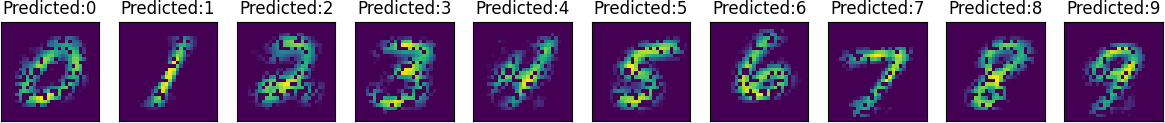
_It would be great if some of you manage to find a solution for the dark (missing) pixels!_     

_Or in case of the fashion set:_

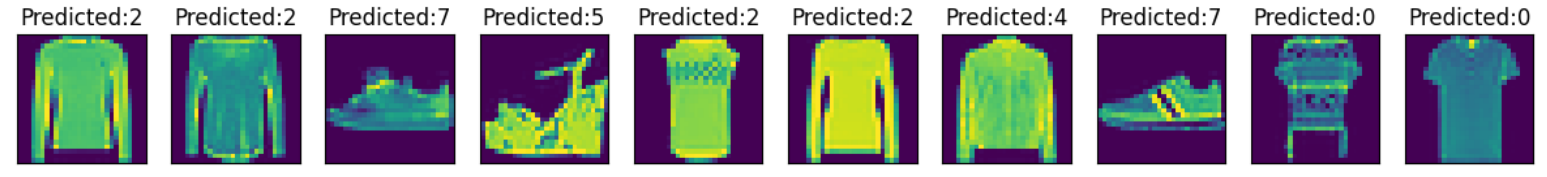

In [ ]:
# Setup the Network
# intialize the neural network
rng = np.random.default_rng()

# number of nodes in each layer
n3 = 10
n4 = 1000
n5 = 784

# input layer n3 - one-hot encoded Y from predictions
# no weights and biases
Y_en = prediction   # prediction = np.argmax(a3, axis=0)  # Shape: (num_samples,)


# hidden layer 4
W4 = rng.normal(0, sqrt(1/n3), size=(n4, n3))
b4 = np.zeros((n4, 1))

# output layer
W5 = rng.normal(0, sqrt(1/n4), size=(n5, n4))
b5 = np.zeros((n5, 1))


# create one-hot encoded Y matrix for the input layer n3
n_rows = int(np.max(Y_en) + 1)
Y_col_en = Y_en.reshape(55000, 1)
Y_hot_en = np.eye(n_rows)[Y_col_en.flatten().astype(int)]
X_de_train = Y_hot_en.T  # the labels are now the input to the next layer 

# prepare Y_de_train, which are now the original images 
Y_de_train = X_train





In [ ]:
# train settings
learning_rate = 0.5
no_epochs = 25
batch_size = 500


In [ ]:
# Train the decoder 

# perform the training
#last layer should be ReLu now, not softmax! (no probabilities now)
accuracies = []
losses = []

accuracies_valid = []
losses_valid = []

for epoch in range(1, no_epochs + 1):
    
    # for each epoch train over all batches
    number_of_batches = int(X_train.shape[1]/batch_size)


    for batch in range(number_of_batches): 
        X_de_batch = X_de_train[:, batch_size*batch : batch_size*(batch+1)]
        Y_de_batch = Y_de_train[:, batch_size*batch : batch_size*(batch+1)]
        
        # forward pass
        # compute the output of the network for the batch
        a3 = X_de_batch
        
        z4 = W4 @ a3 + b4
        a4 = ReLu(z4)

        z5 = W5 @ a4 + b5
        a5 = ReLu(z5)

        
        # backward pass
        # compute the derivatives dLdW and dLdb for the layers (use CE loss)
        dLdz5 = ReLu_diff(z5)*(a5 - Y_batch)
        dLdW5 = dLdz5 @ a4.T
        dLdb5 = dLdz5

        dLdz4 = ReLu_diff(z4)*(W5.T@dLdz5)
        dLdW4 = dLdz4 @ a3.T
        dLdb4 = dLdz4

        
        
        # gradient descent step / update weights and biases
        multiplier = learning_rate/batch_size

        W4 = W4 - multiplier * dLdW4
        b4 = b4 - multiplier*np.sum(dLdb4, axis=1).reshape(-1, 1)

        W5 = W5 - multiplier * dLdW5
        b5 = b5 - multiplier*np.sum(dLdb5, axis=1).reshape(-1, 1)


    
    # for each epoch evaluate the network performance
    # compute accuracy of train set and store for later analysis

    # forward pass for all data
    a3 = X_de_batch
    z4 = W4 @ a3 + b4
    a4 = ReLu(z4)
    z5 = W5 @ a4 + b5
    a5 = ReLu(z5)

#DONE UNTIL HERE


    loss = - np.mean(Y_train*np.log(a3)) # bc softmax 
    losses.append(loss) 
    
    # for each epoch print info on learning progress
    print(f"Epoch {epoch} accuracy: {accuracy:.3}, loss: {loss:.3}")




    # Validation set 

     # forward pass for all validation data
    a0 = X_valid
    z1 = W1 @ a0 + b1
    a1 = ReLu(z1)
    z2 = W2 @ a1 + b2
    a2 = ReLu(z2)
    z3 =  W3 @ a2 + b3
    a3 = softmax(z3)

    # Get predicted class index (argmax along rows → axis=0)
    prediction_valid = np.argmax(a3, axis=0)  # Shape: (num_samples,)



    # Get true class index (argmax along rows → axis=0)
    reference_valid = np.argmax(Y_valid, axis=0)  # Shape: (num_samples,)
    correct_guesses = np.sum(prediction_valid == reference_valid)
    accuracy_valid = correct_guesses / len(reference_valid)
    accuracies_valid.append(accuracy_valid)

    loss_valid = - np.mean(Y_valid*np.log(a3)) # bc softmax 
    losses_valid.append(loss_valid) 

    # for each epoch print info on learning progress
    print(f"Validation: Epoch {epoch} accuracy: {accuracy_valid:.3}, loss: {loss_valid:.3}")



In [ ]:
# Test your image generation and improve your training procedure (hyperparameter tuning)



### Deliverable 1 

In [ ]:
# Prove that your network does what it should do and present your deliverable convincingly!



### Deliverable 2                

In [ ]:
## saves the obtained weights
#outfile='totalweightsNN.npz'
#np.savez(outfile, W1,...,b1,...)
#npzfile = np.load(outfile)
#npzfile.files
#W1=npzfile['arr_0']
#W1.shape


### Deliverable 3               